# Wildfire Risk Prediction

**Goal:** Train a model to predict a property's wildfire risk from its location, using Census socioeconomic data as input features and proximity to historical fire detections as the target.

**Business context:** *[TODO: Write 2-3 sentences on why this matters — insurance underwriting, real estate valuation, urban planning. Who would use this model and how?]*

**Approach:**
1. Generate geographically diverse property locations across CONUS
2. Enrich each property with ~850 Census ACS5 features (income, housing, demographics)
3. Calculate proximity to NASA FIRMS satellite fire detections (VIIRS)
4. Train XGBoost and RandomForest regressors to predict `nearest_fire_km`

**Limitations:** Current run uses county-level Census granularity due to hardware constraints. Tract or block-group level would capture finer neighborhood variation and likely improve results.

In [1]:
import pandas as pd
import load_wildfires
import load_census
import load_properties
import gis
import train
import visualize
import sqlalchemy as s

from pathlib import Path
from sql_funcs import SQL

from settings import PATH_DATA

In [2]:
SQL.kill_idle(True)
sql_obj = SQL()


kill_idle: terminated 8 connection(s)


# Load Properties

## Select Properties of Interest

Chosing 300000 properties randomly from US addresses. We will join relevant census data to these addresses. This will probably take awhile, so best to run it overnight.

We don't care about the address itself. We add a census identifier called the GEOID which based on the coordinate's state, county, and tract number.

Using a package that makes use of the [US Census Geocoder API](https://www.census.gov/programs-surveys/geography/technical-documentation/complete-technical-documentation/census-geocoder.html), requests can be in batches of 10,000.

https://pypi.org/project/random-address/

In [3]:
props = load_properties.Properties(sql_obj=sql_obj)
properties = props.get_properties_gpd()
cur_count = properties.shape[0]
desired_count = 300000
if cur_count < desired_count:
    diff = desired_count - cur_count
    print(f"Adding {diff} more properties...")
    props.add_random_properties_geo_first(diff)


300000 properties loaded.


# Load Features from US Census

2023 US Census Data

Using an API key, we will use the 'census' Python package to interact with the US Govermnent's census API.

In [4]:
import geopandas as gpd

MERGED_PARQUET = PATH_DATA / "merged_properties_census.parquet"

if MERGED_PARQUET.exists():
    print(f"Loading pre-merged data from {MERGED_PARQUET}...")
    combined_gdf = gpd.read_parquet(MERGED_PARQUET)
    print(f"Loaded {len(combined_gdf)} properties with census features.")
else:
    print("No pre-merged file found. Fetching census data from API...")
    census = load_census.CensusData(sql_obj=sql_obj, year=2023, granularity='county')
    combined_gdf = census.merge_census_info(properties)

combined_gdf.head()

Loading pre-merged data from data\merged_properties_census.parquet...
Loaded 300000 properties with census features.


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,B25091_014E,B25091_015E,B25091_016E,B25091_017E,B25091_018E,B25091_019E,B25091_020E,B25091_021E,B25091_022E,B25091_023E
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,0.149341,0.056879,0.033997,0.018242,0.014300,0.010256,0.009368,0.009005,0.024570,0.008219
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,0.097369,0.057454,0.015119,0.017236,0.028122,0.005745,0.000000,0.000000,0.008769,0.000000
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,0.250290,0.074493,0.043701,0.019570,0.014042,0.006302,0.011969,0.013102,0.039002,0.012328
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,0.153632,0.041678,0.019031,0.010505,0.007374,0.005141,0.002201,0.003925,0.011086,0.002309
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,0.156607,0.074042,0.040440,0.022883,0.012523,0.011175,0.007729,0.009077,0.024818,0.002424


# Load Wildfire Data

Wildfire detections from NASA's [FIRMS](https://firms.modaps.eosdis.nasa.gov/) system, using the Visible Infrared Imaging Radiometer Suite (VIIRS) aboard NOAA-21 and Suomi NPP satellites. Each detection is a ~375m pixel with fire radiative power (FRP) in megawatts.

Raw detections are clustered spatiotemporally (DBSCAN: 750m spatial, 3-day temporal) to deduplicate overlapping satellite passes into discrete fire events.

In [5]:
TARGETS_PARQUET = PATH_DATA / "targets_features.parquet"

if TARGETS_PARQUET.exists():
    print(f"Loading pre-computed targets+features from {TARGETS_PARQUET}...")
    targets_features = gpd.read_parquet(TARGETS_PARQUET)
    # Reconstruct proximity column list for drop_cols later
    census_cols = [c for c in targets_features.columns if c.startswith("B")]
    proximity_cols = [c for c in targets_features.columns
                      if c not in census_cols and c not in ["geometry", "geoid"]]
    print(f"Loaded {len(targets_features)} rows x {targets_features.shape[1]} cols "
          f"({len(proximity_cols)} proximity features)")
else:
    print("No pre-computed file found. Running wildfire ETL inline...")
    wildfires = load_wildfires.WildfireData(sql_obj=sql_obj)
    proximity_features = gis.calc_all_features_parallel(combined_gdf, wildfires.data, n_jobs=5)
    targets_features = pd.concat([combined_gdf, proximity_features], axis=1)
    proximity_cols = list(proximity_features.columns)

targets_features.head()

No pre-computed file found. Running wildfire ETL inline...
Loading previously extracted wildfire data from: ['J1V-C2' 'J1V-C2,SV-C2' 'J1V-C2,J2V-C2' 'J1V-C2,J2V-C2,SV-C2' 'J2V-C2'
 'J2V-C2,SV-C2' 'SV-C2']
Loading cached GIS features from gis_features_fbe0faca3786.parquet


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,4055.170447,54.0,171.0,297.0,909.0,719.961429,2122.26,6608.8860,30538.806250,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,1930.528082,0.0,18.0,126.0,135.0,0.000000,1654.02,5819.5800,2380.935000,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,2865.250712,0.0,0.0,288.0,1233.0,0.000000,0.00,7531.3665,28352.104571,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,569.459042,0.0,0.0,63.0,648.0,0.000000,0.00,717.9300,14553.970179,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,169.973961,0.0,0.0,27.0,108.0,0.000000,0.00,406.0800,1294.245000,31.090475


## Proximity Features

Each property gets 12 distance-based features measuring its relationship to nearby wildfires:

| Feature | Description |
|---------|-------------|
| `nearest_fire_km` | Distance to the closest fire event (prediction target) |
| `kde_density` | Kernel density estimate of local fire activity |
| `idw_score` | Inverse-distance-weighted fire intensity within 50 miles |
| `exp_decay_score` | Exponential decay score (captures both proximity and density) |
| `fire_count_10km/25km/50km/100km` | Number of fires within distance rings |
| `fire_FRP_10km/25km/50km/100km` | Cumulative fire radiative power within rings |

In [6]:
targets_features.head()

,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,4055.170447,54.0,171.0,297.0,909.0,719.961429,2122.26,6608.8860,30538.806250,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,1930.528082,0.0,18.0,126.0,135.0,0.000000,1654.02,5819.5800,2380.935000,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,2865.250712,0.0,0.0,288.0,1233.0,0.000000,0.00,7531.3665,28352.104571,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,569.459042,0.0,0.0,63.0,648.0,0.000000,0.00,717.9300,14553.970179,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,169.973961,0.0,0.0,27.0,108.0,0.000000,0.00,406.0800,1294.245000,31.090475


# Exploratory Data Analysis

*[TODO: Write 2-3 sentences summarizing what you observed in the EDA. What patterns stand out? Any surprises in the data distributions or missingness?]*

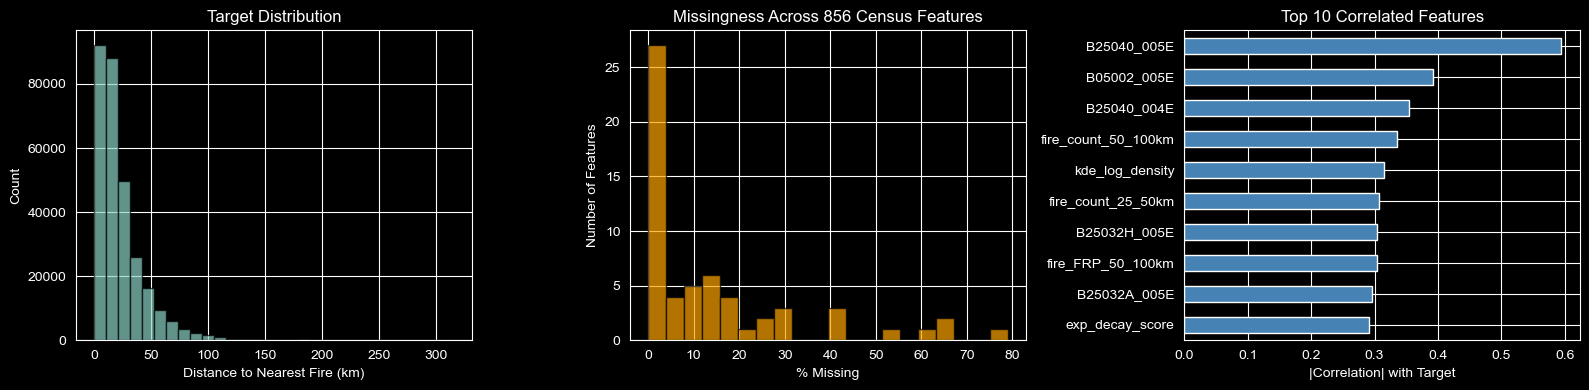


Dataset: 300000 properties, 870 columns
Census features: 856
Features with missing data: 60
Target range: 0.0 – 315.5 km


In [8]:
eda = visualize.eda(targets_features)

# Machine Learning Considerations

## Scoring Method

Using RMSE (Root Mean Squared Error) as the primary metric. Its quadratic penalty on large errors aligns with the business case: underestimating wildfire risk (predicting a property is far from fires when it isn't) is costly for an insurance company.

## Target Variable

`nearest_fire_km` — the distance in kilometres to the nearest wildfire detection.

With a larger dataset, `exp_decay_score` (which captures both proximity and density of nearby fires) would be a stronger target choice.

# Preprocessing and Training

## Split Data into Features/Targets

We use `nearest_fire_km` as the target — the distance in kilometres to the nearest wildfire detection. With the full 300k-property dataset, `exp_decay_score` (which captures both proximity and density of nearby fires) would be a better choice, but the small 119-property test set has nearly zero variance in decay score because all properties are ~360 km from the nearest fire.

All other proximity-derived columns are dropped so the model only sees census features as inputs.

In [12]:
TARGET_COL = "nearest_fire_km"

# All proximity features are derived from the same wildfire data — drop them
# so the model only sees census features as inputs.
drop_cols = ["geometry", "geoid"] + [c for c in proximity_cols if c != TARGET_COL]

# Preprocessing with adaptive imputation based on missingness analysis
# - MCAR features: SimpleImputer (median) - fast
# - MAR features: IterativeImputer - preserves correlations
X_train, X_test, y_train, y_test, feature_names, pipeline = train.preprocess_with_cache(
    targets_features,
    TARGET_COL,
    drop_cols,
    nan_threshold=0.45,
    corr_threshold=0.85,
    mar_corr_threshold=0.1,
    use_cache=True,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: {y_train.min():.4f} – {y_train.max():.4f}")
print(f"Target std:   {y_train.std():.6f}")
print(f"Target mean:  {y_train.mean():.4f}")

Loading cached preprocessing from preprocess_d270d9dd766b.pkl
  Loaded 556 features from cache
Train: (240000, 556), Test: (60000, 556)
Target range: 0.0329 – 315.4585
Target std:   27.494053
Target mean:  24.4749


In [13]:
# Diagnostic: check if the target has meaningful variance
cv = y_train.std() / y_train.mean() * 100  # coefficient of variation
print(f"Coefficient of variation: {cv:.4f}%")
if cv < 1.0:
    print(
        f"WARNING: Target has near-zero variance (CV={cv:.4f}%). "
        f"All properties are ~{y_train.mean():.1f} km from the nearest fire. "
        f"Models will appear to have perfect accuracy but are not learning meaningful patterns. "
        f"Scale to 300k properties for geographic diversity."
    )

Coefficient of variation: 112.3358%


## Preprocessing

Drop high-NaN columns, remove correlated features, then impute + scale. All steps are fit on training data only to prevent leakage.

**Adaptive Imputation:** The preprocessing analyzes each feature's missingness mechanism:
- **MCAR** (Missing Completely At Random): Uses `SimpleImputer(median)` - fast, O(n)
- **MAR** (Missing At Random): Uses `IterativeImputer` - preserves feature correlations

**Caching:** Results are cached to `data/cache/preprocess_{hash}.pkl`. Re-runs with unchanged data load from cache in <1s.

## Model Training


### RandomForestRegressor


In [14]:
rfr_search = train.train_random_forest(X_train, y_train, n_iter=20, cv=5)
print(f"Best RF params: {rfr_search.best_params_}")

rfr_metrics = train.evaluate_model(rfr_search.best_estimator_, X_train, X_test, y_train, y_test)
print(f"RF Train RMSE: {rfr_metrics['train_rmse']:.8f}")
print(f"RF Test  RMSE: {rfr_metrics['test_rmse']:.8f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'max_depth': 44, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 927}
RF Train RMSE: 8.53712090
RF Test  RMSE: 8.74250298


### XGBoost


In [15]:
xgb_search = train.train_xgboost(X_train, y_train, n_iter=20, cv=5)
print(f"Best XGB params: {xgb_search.best_params_}")

xgb_metrics = train.evaluate_model( xgb_search.best_estimator_,
                                   X_train, X_test, y_train, y_test)
print(f"XGB Train RMSE: {xgb_metrics['train_rmse']:.8f}")
print(f"XGB Test  RMSE: {xgb_metrics['test_rmse']:.8f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\jdcf5\anaconda3\envs\GIS\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGB params: {'colsample_bytree': np.float64(0.7355789407775537), 'gamma': np.float64(0.42855130361271904), 'learning_rate': np.float64(0.10614654887463763), 'max_depth': 11, 'min_child_weight': 2, 'n_estimators': 659, 'reg_alpha': np.float64(0.3544317346711524), 'reg_lambda': np.float64(0.5498989637627353), 'subsample': np.float64(0.9187783443855757)}
XGB Train RMSE: 8.53752339
XGB Test  RMSE: 8.74332428


## Model Comparison

*[TODO: Write 2-3 sentences comparing the models. Which won and why? Is the gap meaningful? What does the train/test RMSE gap tell you about overfitting?]*

- Very similar, RFR slightly better.
- Root mean squared error of about 8.5-9km, which is quite accurate considering the size of the contiguous USA.
- RFR model is much slower to train and the final model is 40X larger on the hard disk, but not particularly oversized.
- The similarity between train and test RMSE suggests the data is not overfitting to the training data.
- The $R^2$~0.9 also suggests the model matches the observations quite well.
-

In [16]:
comparison = pd.DataFrame({
    "RandomForest": train.full_metrics(rfr_search.best_estimator_, X_train, X_test, y_train, y_test),
    "XGBoost": train.full_metrics(xgb_search.best_estimator_, X_train, X_test, y_train, y_test),
})
comparison

,RandomForest,XGBoost
Train RMSE,8.537121,8.537523
Test RMSE,8.742503,8.743324
Test MAE,6.186373,6.187422
Test R²,0.898841,0.898822


## Feature Importance

*[TODO: Write 2-3 sentences interpreting the top features. What do the most important census features tell you about which neighborhoods are closer to wildfires? Do the results make intuitive sense?]*

In [17]:
#Pick the better model
if xgb_metrics["test_rmse"] <= rfr_metrics["test_rmse"]:
    best_model = xgb_search.best_estimator_
    print("Best model: XGBoost")
else:
    best_model = rfr_search.best_estimator_
    print("Best model: RandomForest")
feature_names = [load_census.census_code_to_label(x) for x in feature_names]

top_features = train.extract_feature_importance(best_model, feature_names, top_n=10)
print(f"\nTop 10 features:\n{top_features}")

Best model: RandomForest

Top 10 features:
House Heating Fuel: Fuel oil, kerosene, etc.                                             0.034938
Place Birth/Nativity Citizenship: Born in other state in the United States: Northeast    0.023295
House Heating Fuel: Electricity                                                          0.019478
Total Population/Tenure/Units Structure: Owner occupied: 2 to 4                          0.017732
Place Birth/Nativity Citizenship: Naturalized U.S. citizen: Northern America             0.012577
Place Birth/Nativity Citizenship: Born in other state in the United States: Midwest      0.010197
Units in Structure: 3 or 4                                                               0.009865
Tenure/Units Structure: Renter-occupied housing units: 1, detached                       0.009639
Place Birth/Nativity Citizenship: Not a U.S. citizen: Northern America                   0.009606
House Heating Fuel: Utility gas                                            

Figure saved to figures\feature_importance.png


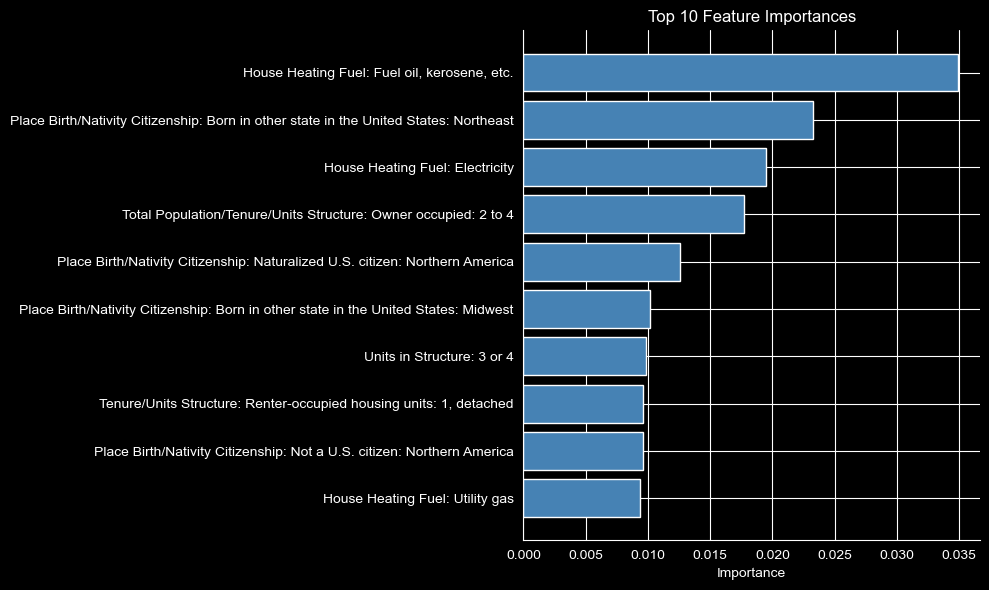

In [23]:
# Feature importance bar chart
fig_importance = visualize.plot_feature_importance(
    top_features, 
    title="Top 10 Feature Importances",
    save_path=Path("figures/feature_importance.png")
)

Figure saved to figures\actual_vs_predicted.png


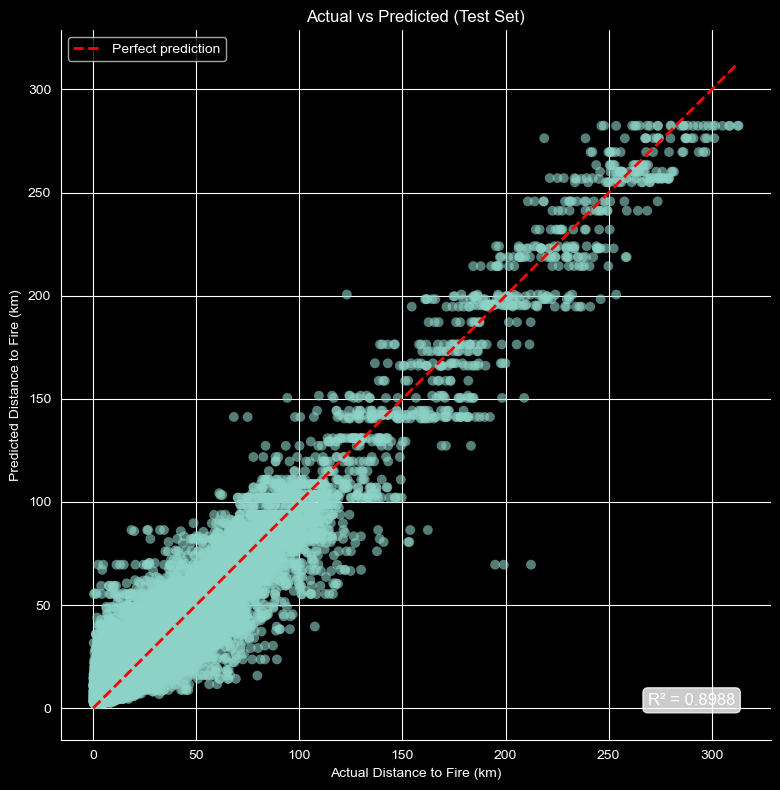

In [24]:
# Actual vs Predicted scatter plot
y_pred = best_model.predict(X_test)

fig_scatter = visualize.plot_actual_vs_predicted(
    y_test.values, 
    y_pred,
    title="Actual vs Predicted (Test Set)",
    xlabel="Actual Distance to Fire (km)",
    ylabel="Predicted Distance to Fire (km)",
    save_path=Path("figures/actual_vs_predicted.png")
)

In [25]:
model_path = Path("Models") / "best_model.pkl"
train.save_model(best_model, model_path, pipeline=pipeline, feature_names=feature_names)
print(f"Model saved to {model_path}")

Model saved to Models\best_model.pkl


# Conclusion

*[TODO: Write your conclusion. Cover these points:]*

*1. **What did the model learn?** Can census features predict wildfire proximity? How well?*

*2. **Key findings:** Which feature groups mattered most? Any surprising predictors?*

*3. **Limitations:** Small sample size (119 properties), county-level granularity, single year of fire data, proximity != actual risk*

*4. **Business recommendation:** How would you use this model? What confidence level is needed before acting on predictions?*

*5. **Next steps:** Scale to 300k properties, add vegetation/weather/topography features, try finer geographic granularity, add a neural network model for comparison*